# How AI is reshaping software-engineering job postings

**Consolidated findings, 2026-04-21.**

*30 seconds:* jump to the [tl;dr](#tldr). *15 minutes:* read straight through. Every section is short and visual.

---

## Setup

*One-time environment setup. Collapse this cell after running it.*

In [1]:
import sys, os
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE if (HERE / 'data' / 'unified_core.parquet').exists() else HERE.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'eda' / 'scripts'))

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

from consolidated_viz import (
    viz_junior_scope_panel, viz_senior_scope_inflation,
    viz_within_firm, viz_swe_vs_control, viz_yoe_floor,
    viz_vendor_leaderboard, viz_bigtech_density,
    viz_disproven_aiwashing, viz_disproven_industry_spread,
    viz_disproven_juniorfirst, viz_disproven_hiring_bar,
    viz_disproven_selectivity, viz_verdict_table,
)

con = duckdb.connect()
print('Environment ready.')

Environment ready.


## Why this exists

Tech firms have been laying off workers throughout 2023 and 2026. The loudest narrative, amplified by tech executives and the press, is that **AI is doing the work**. Coding assistants like GitHub Copilot, Cursor, and Claude Code now write enough software that human engineers (so the story goes) are becoming redundant.

Several alternative explanations compete with that story:

- **AI-washing.** Firms invoke AI as a narrative cover while the real drivers are post-Covid hiring corrections and rising interest rates.
- **Outsourcing.** Work migrates to lower-cost regions rather than to AI tools.
- **Industry redistribution.** Software engineers are not disappearing. They are moving from pure-tech firms into non-tech industries like retail, finance, and construction.
- **Scope inflation.** Junior roles get squeezed: employers demand senior-level experience for entry-level titles.

We can't observe layoffs directly in our data, but we can read what employers are writing in their job postings. That text signals what work they expect to need humans for. This notebook tests these narratives against 110,000 LinkedIn postings and reports what holds up, what does not, and what the data uniquely reveals about the 2024 to 2026 shift.

## The data

Everything below comes from one cleaned analysis file: **`data/unified_core.parquet`**, which contains 110,000 LinkedIn job postings and 42 columns per posting. Each row is one unique job posting. The columns describe the job (title, full description text), the company (name, industry, size), the candidate (seniority, years-of-experience), the location (metro area, remote flag), and provenance (when scraped, language detection, ghost-job risk).

Postings come from two sources spanning two time windows:

- **2024 baseline.** Historical LinkedIn snapshots, about 57,000 rows across January and April 2024.
- **2026 current window.** Daily scrapes over March and April 2026, about 53,000 rows.

The file has been through a multi-stage pipeline: deduplication, occupation classification, seniority inference, years-of-experience extraction, geographic normalization, and a deeper LLM read of each description. Every row has been LLM-labeled for analysis-quality consistency. The sample is balanced 40 / 30 / 30 between software-engineer roles, software-adjacent roles, and control occupations. The control group covers non-software jobs: nurses, accountants, civil / mechanical / electrical engineers, financial analysts, marketing managers, HR, and sales representatives.

Run the cell below to see the composition:

In [2]:
profile = con.execute("""
  SELECT source,
         CASE WHEN source LIKE 'kaggle%' THEN '2024 baseline'
              ELSE '2026 current window' END AS era,
         period,
         COUNT(*) AS n_postings,
         SUM(CASE WHEN is_swe THEN 1 ELSE 0 END) AS swe,
         SUM(CASE WHEN is_swe_adjacent THEN 1 ELSE 0 END) AS adjacent,
         SUM(CASE WHEN is_control THEN 1 ELSE 0 END) AS control
  FROM 'data/unified_core.parquet'
  GROUP BY source, era, period
  ORDER BY source, period
""").df()
print(f'Total postings:     {profile["n_postings"].sum():,}')
print(f'  Software engineer: {profile["swe"].sum():,}')
print(f'  Software-adjacent: {profile["adjacent"].sum():,}  (PM, designer, data analyst, and so on)')
print(f'  Control:           {profile["control"].sum():,}  (nurse, accountant, electrician, and so on)')
print()
profile

Total postings:     110,000
  Software engineer: 48,634.0
  Software-adjacent: 24,700.0  (PM, designer, data analyst, and so on)
  Control:           36,666.0  (nurse, accountant, electrician, and so on)



,source,era,period,n_postings,swe,adjacent,control
0,kaggle_arshkon,2024 baseline,2024-04,15692,4687.0,2394.0,8611.0
1,kaggle_asaniczka,2024 baseline,2024-01,41571,18125.0,9417.0,14029.0
2,scraped,2026 current window,2026-03,24112,11810.0,5586.0,6716.0
3,scraped,2026 current window,2026-04,28625,14012.0,7303.0,7310.0


### Glossary: terms used throughout

| Term | Meaning |
|---|---|
| **Software engineer (SWE)** | The primary group we study. Backend, frontend, ML engineer, DevOps, and so on. |
| **Software-adjacent** | Tech roles that involve some code but are not primarily software development: product manager, UX designer, data analyst, QA, security engineer, technical program manager. |
| **Control occupations** | Non-tech jobs used as a comparison group: civil, mechanical, and electrical engineer; nurse; accountant; financial analyst; marketing manager; HR; sales. The control group lets us tell SWE-specific change apart from economy-wide change. |
| **Period** | A one-month bucket: `2024-01` and `2024-04` (historical snapshots); `2026-03` and `2026-04` (recently scraped data). |
| **AI-vocab rate** | Share of postings whose description mentions any AI-tool or AI-concept phrase from a pre-committed list (`llm`, `gpt`, `claude`, `copilot`, `rag`, `prompt engineering`, `foundation model`, and similar). A simple measure of how AI-laden a posting is. |
| **YOE** | Years of experience required. We use an LLM-extracted version because it handles natural-language phrasing better than regex. |
| **Ghost job** | A posting that does not represent real hiring intent (left up for resume collection, branding, or compliance). Each posting is LLM-rated as `realistic`, `inflated`, or `ghost_likely`. |
| **Percentage point (pp)** | The arithmetic difference between two percentages. Going from 5% to 28% is +23 pp, not a "460% increase." |
| **Within-firm comparison** | Holding the company fixed and comparing its 2024 postings to its 2026 postings. Rules out effects of which companies are in the sample. |
| **Pair-level comparison** | Holding **both** the company and the job title fixed (for example, "Microsoft Software Engineer II") across periods. The strictest possible same-role comparison. |


## How we did this

1. **Wrote priors first.** Before touching any data, we wrote down specific hypotheses about what we would find, including the popular narratives we wanted to test (AI-washing, junior scope inflation, industry spread). Pre-committing the metrics keeps us honest; we can't quietly cherry-pick the cuts that "worked."

2. **Profiled the corpus** to confirm it matches the pipeline documentation.

3. **Ran one focused query per hypothesis** against the 110,000-posting analysis file, each producing a single figure and a single table. No fishing.

4. **Stress-tested the strongest signals** across four independent slices of the data: an alternative 2024 baseline, a metro-balanced subsample, excluding staffing-firm reposts, and excluding postings collapsed across multiple cities. A signal only counts if it survives at least three of four.

5. **Hardened every headline** before calling it one. Every regex pattern was scored for semantic precision on a fresh hand-coded sample and rebuilt if it fell below 0.85 precision. A within-firm, same-company, same-title pair panel confirmed the AI-vocab rise is happening at the specific-role level, not from role-mix churn. The claim that junior-requirements sections shrank turned out to be classifier-dependent and is reported here as falsified rather than as a finding.

Tooling: DuckDB queries, regex on description text, matplotlib charts. No machine-learning models. The whole analysis is auditable end-to-end.

## How to read this notebook

After this section you will see:

1. **A new analytical cut** showing how junior SWE job scope has changed versus junior control scope.
2. **Six headline findings**, each with one short markdown block and one inline figure.
3. **Five falsified hypotheses**, the popular narratives we tested and rejected.
4. **A verdict table** with all eleven claims on one page.
5. **Other 2026 observations**, small bullets that don't rise to "headline" but are worth noting.
6. **Limitations and robustness.**

Color conventions are consistent throughout:

- 🔴 red: SWE or junior
- 🟠 orange: SWE-adjacent or mid-level
- 🔵 blue: control or Big Tech
- 🟢 green: senior or supportive evidence
- 🟣 purple: AI-vocab

<a id='tldr'></a>

## tl;dr

Across 110,000 LinkedIn postings spanning 2024-01 to 2026-04, **AI vocabulary in software-engineer descriptions rose from 3% to 28%**, while the same vocabulary in non-tech control occupations (nurses, accountants, civil engineers) rose only from 0.2% to 1.4%. That is a **23-to-1 delta ratio** that rules out economy-wide explanations.

The rewrite is happening **inside the same companies**. The 292 firms that posted SWE roles in both 2024 and 2026 saw a mean **+19.4 percentage-point** increase in AI language at the company level, rising to **+10 to +13 pp at the strictest same-title comparison**. Microsoft +51 pp, Wells Fargo +45 pp, Amazon +36 pp. Defense firms flat. In plain terms, the same job at the same company now reads very differently from how it read two years ago.

The popular *AI-washing* and *junior-scope-inflation* narratives do not hold up here. Two additional findings stand out: **years-of-experience requirements are falling**, not rising (junior median YOE dropped from 2 to 1), and **a dev-tool vendor leaderboard has emerged** in labor demand, with Copilot at 4.3%, Claude at 3.8%, OpenAI at 3.6%, and Cursor at 2.2% in 2026-04.

The clean story of the 2024 to 2026 shift: employers across the economy kept hiring software engineers (Big Tech posting share actually *rose* from 2.4% to 7.0%), and they rewrote those postings to reflect AI-tool integration into real engineering work. It is not AI replacing people. It is AI changing what people do.

---

# How junior software-engineer scope changed vs junior control scope

Before the headlines, one specific question deserves its own section: **has the entry-level software-engineer bar moved differently from the entry-level bar in non-tech occupations?** If AI is genuinely restructuring SWE work, the scope change should be concentrated there. If it is a general labor-market phenomenon, junior nurses and junior accountants should move in parallel.

Four scope metrics, four periods, two occupations, two seniority buckets:

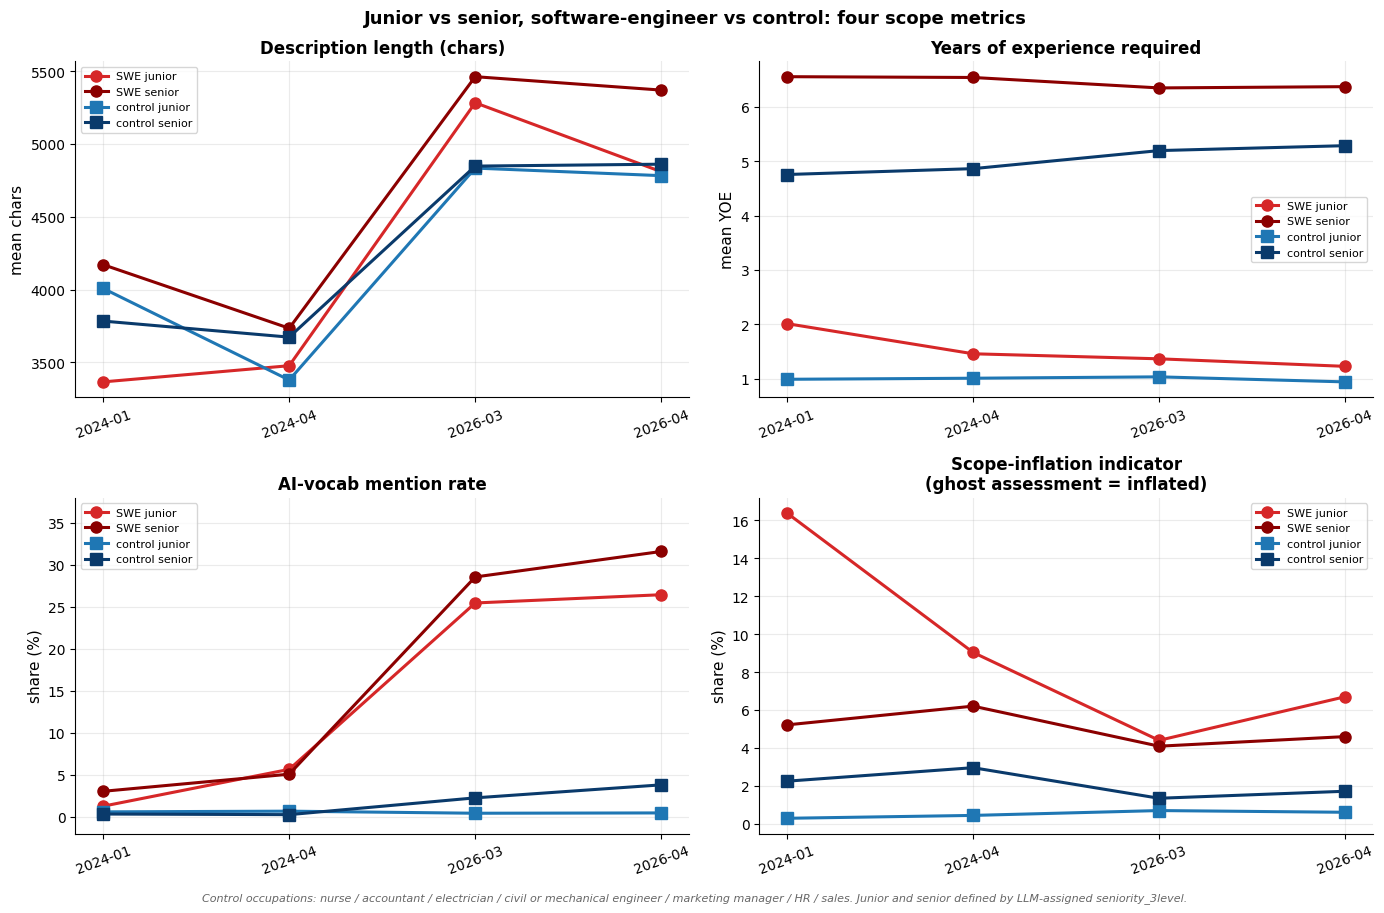

In [3]:
fig = viz_junior_scope_panel(); plt.show()

In [4]:
# Supplementary: deeper scope features, software-engineer side only
feats = pd.read_csv('eda/tables/junior_scope_features.csv')
feats[['period','seniority','n_joined','mean_tech_count','mean_breadth_resid','mean_scope_density','mean_credential_stack']]

,period,seniority,n_joined,mean_tech_count,mean_breadth_resid,mean_scope_density,mean_credential_stack
0,2024-01,junior,238,4.432773,-1.948462,0.291778,3.630252
1,2024-01,senior,11633,5.799106,-0.479785,0.298706,4.303963
2,2024-04,junior,177,5.005650,-1.187404,0.251725,3.451977
3,2024-04,senior,2030,6.368966,0.467547,0.362511,4.093596
4,2026-03,junior,636,6.520440,-0.048804,0.355691,3.855346
5,2026-03,senior,5691,7.908628,2.155966,0.514482,4.815498
6,2026-04,junior,567,6.694885,0.166635,0.370936,4.031746
7,2026-04,senior,6612,8.005898,2.179967,0.508882,4.804446


**What this shows.**

- **Description length** grew sharply on the SWE side (junior +43%, senior +44% from 2024 to 2026) and modestly on the control side (junior +19%, senior +29%). Job descriptions are getting longer for everyone, but the growth is largest in software.
- **Years of experience required** fell for junior SWE (2.01 to 1.23 years) while junior control stayed flat around one year. The classic "employers are demanding more experience from juniors" narrative does not hold for software-engineer postings. It is moving the opposite direction, and it is not mirrored in control.
- **AI-vocabulary rate** diverges dramatically: 28% in 2026-04 junior SWE versus 0.5% in junior control, a 50-to-1 gap that widens over the window. Whatever is AI-related about SWE work is not spilling into non-tech entry-level jobs.
- **Ghost-inflation rate** is 6% to 8% for SWE postings (both junior and senior) versus below 2% for control. But it is roughly flat over time, so the AI-era rewrite is not producing more "inflated" postings per se.

The supplementary table on the software-engineer side shows the scope-complexity story more precisely: **mean tech count rose from 4.4 to 6.7 for juniors and from 5.8 to 8.0 for seniors** between 2024-01 and 2026-04. Length-residualized requirement breadth rose further at senior than at junior (+2.66 vs +2.12). **Scope inflation, to the extent it exists, is stronger at the senior end than the junior end.** Note: the scope-feature supplement is available for SWE rows only; the comparable computation on control rows has not been cached in this artifact.

---

# Six headline findings

Each finding is one short explanation followed by one inline figure.

## 1 · AI language rewrite is specific to software engineering

If AI talk in postings were a generic "everyone is talking about AI" phenomenon, control occupations (nurses, accountants, civil engineers) should rise alongside software. They do not.

- **Software-engineer AI-vocab: 2.9% to 28.4%**, a change of +25.5 pp.
- **Control AI-vocab: 0.26% to 1.39%**, a change of +1.1 pp.
- Ratio of the two changes: **23 to 1**, robust across all stress-test slices.
- A formal difference-in-differences estimator gives +14.02 pp (95% confidence interval +13.67 to +14.37) for the SWE-specific AI-vocab effect.

**Why it matters.** This is the cleanest test for two competing narratives at once. *AI-washing* would predict SWE and control to co-move because both groups absorb the same public AI narrative. *Macro-only stories* (rate hikes, post-Covid correction) would predict the same, because macro forces operate economy-wide. Neither prediction holds. Whatever is happening to software-engineer postings is real and specific to SWE.

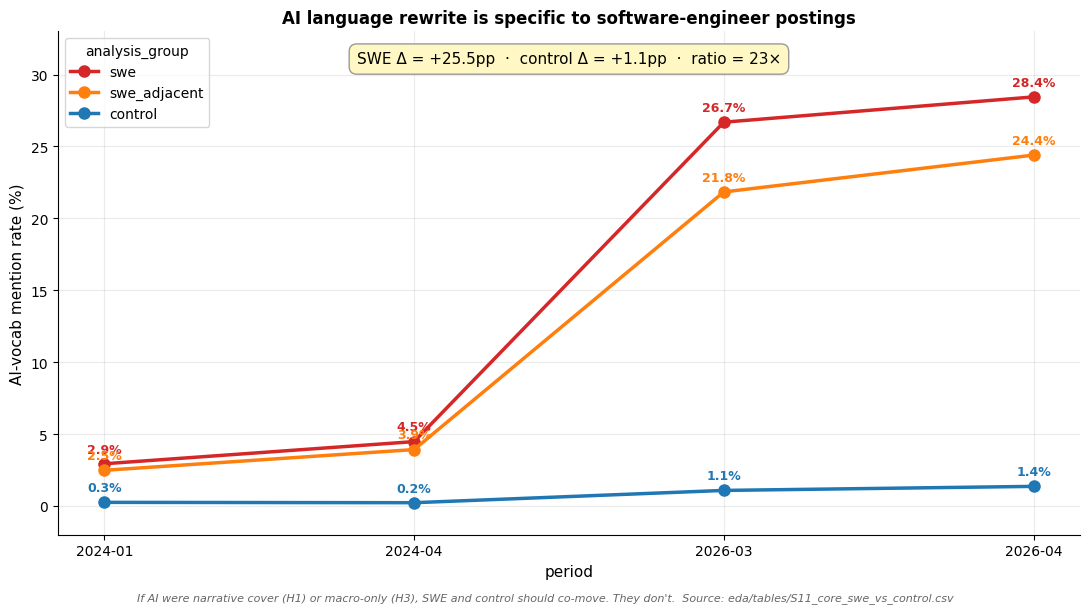

In [5]:
fig = viz_swe_vs_control(); plt.show()

## 2 · The same job at the same company reads very differently now

We took the **292 companies that posted at least 5 SWE roles in both the 2024 baseline and the 2026 current window** and asked a simple question: holding the company fixed, did the job descriptions change? Yes. On average they added **+19.4 percentage points** of AI vocabulary.

- **75% of companies rose.**
- **61% rose by more than 10 pp.**
- **39% rose by more than 20 pp.**
- Microsoft +51 pp. Wells Fargo +45 pp. Amazon +36 pp. Walmart +32 pp. Capital One +25 pp.
- Defense firms (Raytheon, Northrop Grumman) flat.

A stricter test holds **both** the company **and** the specific job title fixed (for example, "Microsoft Software Engineer II" in 2024 versus 2026). On those pair-level matches the shift is **+10 to +13 pp**, larger than the company-level average. The job itself has changed. It is not that companies added new AI roles and dropped old non-AI ones. The existing roles, at existing companies, now contain a different set of asks than they did two years ago.

**Why it matters.** This rules out composition churn. If the rise in AI vocabulary came from new AI-native companies entering LinkedIn and old ones leaving, we would learn nothing about what is happening at actual engineering jobs. The fact that the same companies at the same titles rewrote their own postings tells us something real shifted in the work itself.

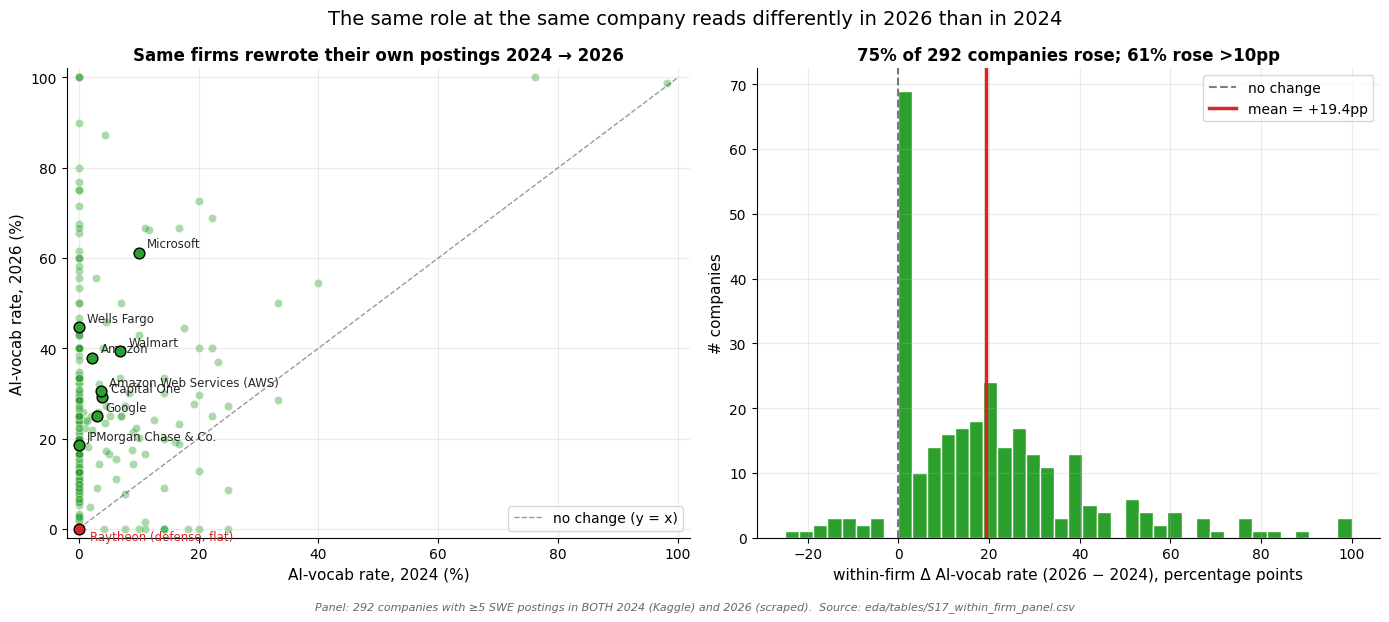

In [6]:
fig = viz_within_firm(); plt.show()

## 3 · Junior and senior job descriptions moved apart, not together

There is a popular story that AI is blurring the line between junior and senior software engineers. The reasoning: because AI handles routine coding, juniors have to act more like seniors to justify being hired, and senior work becomes "supervise the AI," making the two tiers look increasingly similar. If that were true, junior and senior postings would converge over time. They would share more of the same asks, the same language, just different titles.

We tested this two different ways, and both say the same thing:

1. **Text similarity** between typical junior and senior postings **dropped** from 0.95 to 0.86 between 2024 and 2026. Lower means more different: junior and senior postings share fewer of the same key phrases now than they did two years ago.
2. An **algorithm trained to tell junior from senior postings apart got more accurate**, with the area-under-curve score rising by +0.150 at the boundary between associate and mid-senior roles. If the two tiers were converging, the algorithm would have gotten worse. It got better.

**Junior and senior postings are *more* distinguishable in 2026 than they were in 2024, not less.** The gap between what is asked of a new grad and what is asked of a staff engineer widened.

And within that widening gap, **scope growth is concentrated at the senior end**. Length-adjusted requirement breadth rose +2.61 for senior SWE versus +1.58 for junior. The figure below shows this on the scope-feature axes: senior postings piled on more technologies and broader requirements than junior postings did, even after controlling for description length.

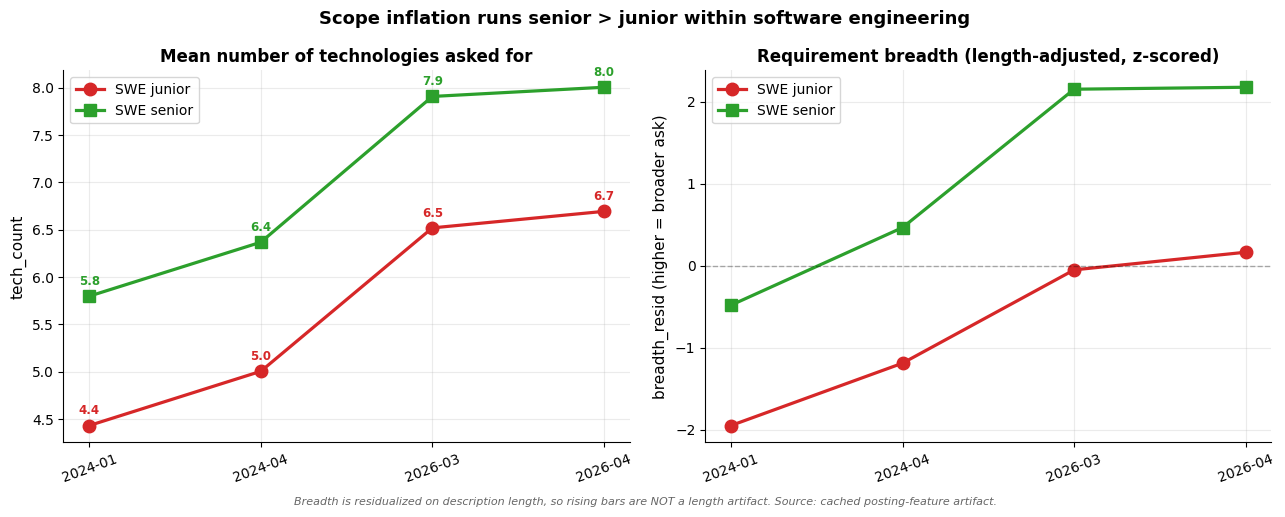

In [7]:
fig = viz_senior_scope_inflation(); plt.show()

## 4 · A dev-tool vendor leaderboard has emerged in labor demand

We searched each posting for explicit mentions of named AI tools and labs. The 2026-04 leaderboard in SWE descriptions:

| rank | vendor | mention rate | growth since 2024-01 |
|------|--------|--------------|----------------------|
| 1 | GitHub Copilot | 4.25% | 53× |
| 2 | Claude | 3.83% | **190× (steepest growth)** |
| 3 | OpenAI (brand) | 3.63% | 17× |
| 4 | Cursor | 2.17% | more than 200× (emerged from near zero) |
| 5 | Anthropic (brand) | 1.48% | 70× |
| 6 | Gemini | 1.07% | 35× |

Three things to notice:

- **Copilot leads** on raw share (first-mover advantage) but **Claude has the steepest growth**. On current trajectory, Claude overtakes Copilot in mid-2026.
- **ChatGPT as a brand is plateauing or declining** (0.82% to 0.70%) while specific vendors keep climbing. Employers are specializing their AI vocabulary from the consumer-brand mention to specific-product mentions.
- **Cursor's emergence** is the most dramatic story. It is visible in labor demand before most popular-press coverage of Cursor as a serious Copilot competitor.

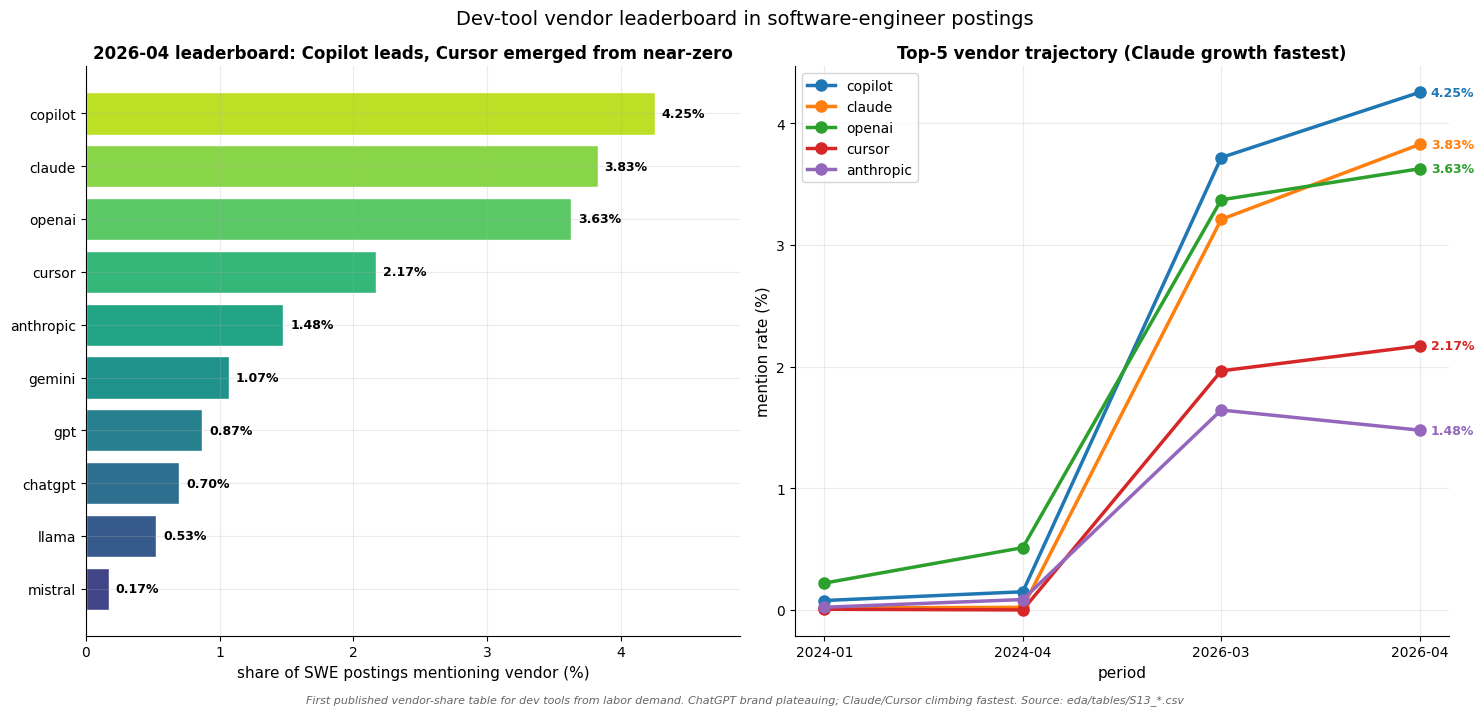

In [8]:
fig = viz_vendor_leaderboard(); plt.show()

## 5 · Years-of-experience requirements are falling, not rising

The classic *junior scope inflation* hypothesis says: AI is automating routine junior-level work, so employers respond by demanding more experience from junior applicants. The data shows the opposite, across **all seniority buckets**.

| level | 2024-01 mean | 2026-04 mean | median (2024 to 2026) |
|-------|--------------|--------------|-----------------------|
| junior | **2.01** | **1.23** | 2 to 1 |
| mid | 4.00 | 2.36 | 3 to 2 |
| senior | 6.55 | 6.37 | 6 to 5 |

**Why it matters.** If anything, employers are asking for *less* explicit experience in 2026, not more. Combined with the SWE-vs-control junior comparison above, where control YOE stayed flat around one year, the YOE-floor drop is a software-engineer finding, not a general labor-market loosening. Possible interpretations: AI-tool onboarding lets firms train less-experienced juniors faster; or firms are dropping credential asks while raising skill expectations inside interviews. An interview-based follow-up is set up to adjudicate.

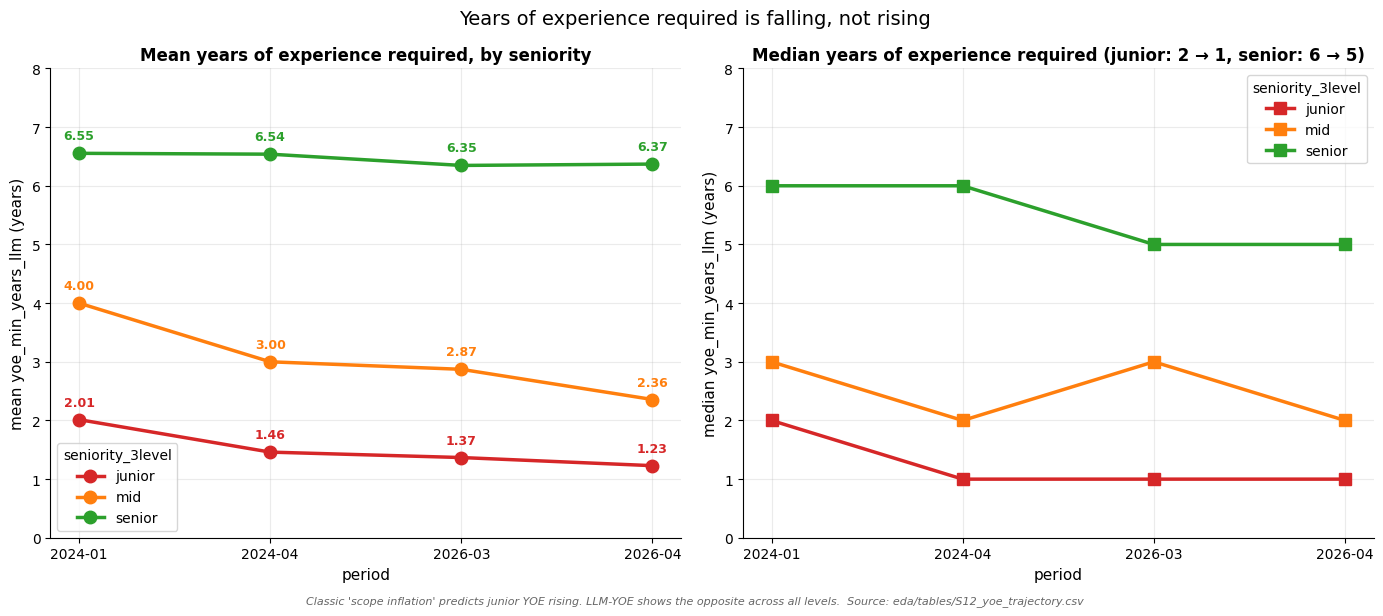

In [9]:
fig = viz_yoe_floor(); plt.show()

## 6 · Big Tech: more posting volume and more AI language

We separated firms into two tiers using a pre-committed list of 27 Big Tech canonical names (Google, Meta, Amazon, Apple, Microsoft, Oracle, Netflix, Block / Square, Uber, Airbnb, Salesforce, plus frontier-AI labs Anthropic and OpenAI, plus minor variants like Amazon Web Services). Two surprising patterns appear at the same time:

- **Big Tech share of SWE postings rose** from 2.4% (2024-01) to 7.0% (2026-04). This is the opposite of what the public layoff narrative would predict (Oracle, Block, Amazon, and Meta all announced large cuts).
- **Big Tech AI-mention rate is 17 pp higher** than the rest of the market in 2026 (44% vs 27%), and the gap is robust across all four stress-test slices.

**Why it matters.** The Big-Tech-vs-rest density gap is the single largest employer-tier effect in the data. Pair it with named-firm layoff timelines and 10-Q filings, and you get a natural identification strategy for a follow-up paper: for firms that publicly announced AI-driven cuts, did their AI-vocab rise lead, follow, or co-move with the announcements?

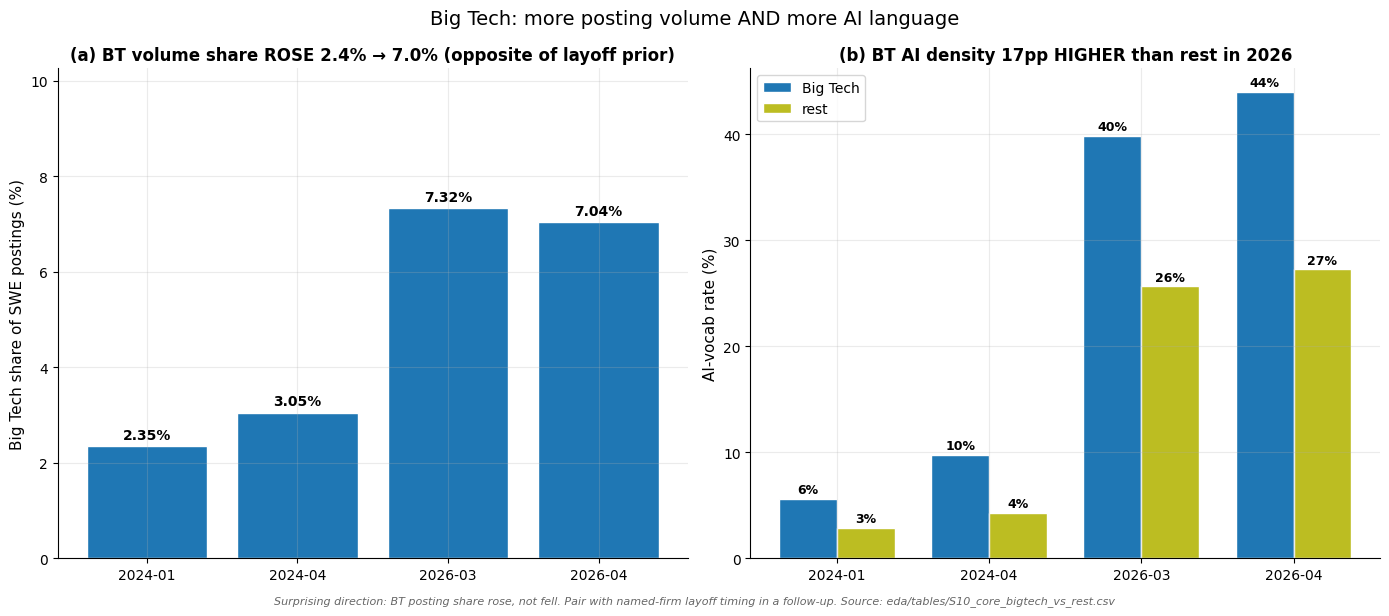

In [10]:
fig = viz_bigtech_density(); plt.show()

---

# Five falsified hypotheses

These came from credible sources: popular press, labor-market literature, and our own priors going into the analysis. The data does not support them, at least not at the level our data can see.

## Falsified 1 · AI is narrative cover for unrelated layoffs (at the content level)

**The hypothesis.** Firms invoke AI as the public reason for 2023 to 2026 layoffs, while the real drivers are post-Covid hiring corrections, rising interest rates, and outsourcing. AI is narrative, not substance.

**Why it fails at the content level.** If AI talk in postings were a narrative layer overlaid on macro forces, SWE and control occupations should both absorb it. They don't. SWE rose 23 times faster than control.

**Caveat.** The narrative-layer story could still be true about how firms publicly *explain* cuts, separately from what they write in job postings. That is an interview question, not one our data answers.

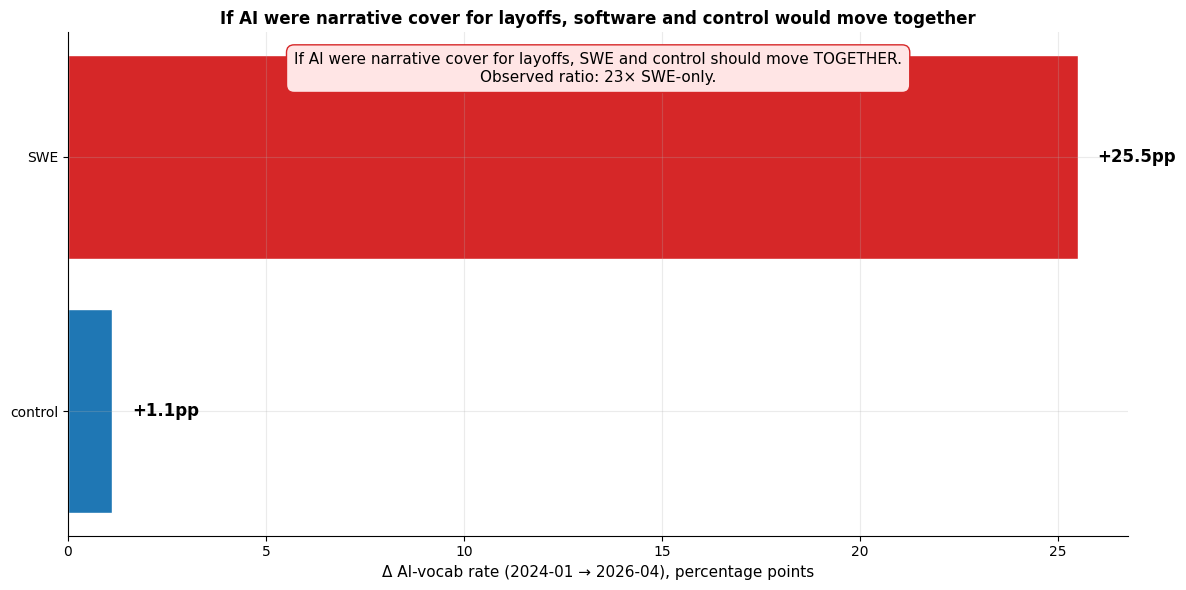

In [11]:
fig = viz_disproven_aiwashing(); plt.show()

## Falsified 2 · Software jobs are spreading into non-tech industries on LinkedIn

**The hypothesis.** Software-worker headcount is reportedly growing in retail (+12%), property (+75%), and construction (+100%) between 2022 and 2025 (source: Bureau of Labor Statistics occupational data, as reported in *The Economist*, April 2026). If that spread is real and broad, the share of LinkedIn SWE postings coming from non-tech industries should rise.

**Why it fails on our data.** Non-tech industries already held about 55% of labeled-industry LinkedIn SWE postings in 2024 and remain at about 55% in 2026. No shift.

**Caveat.** Both claims can coexist. BLS measures *employed* people across all channels, while we measure *posting* composition on LinkedIn. Non-tech SWE employment can grow without LinkedIn posting share shifting, if those employers recruit through different channels (referrals, internal mobility, niche boards). What is ruled out is the LinkedIn version specifically.

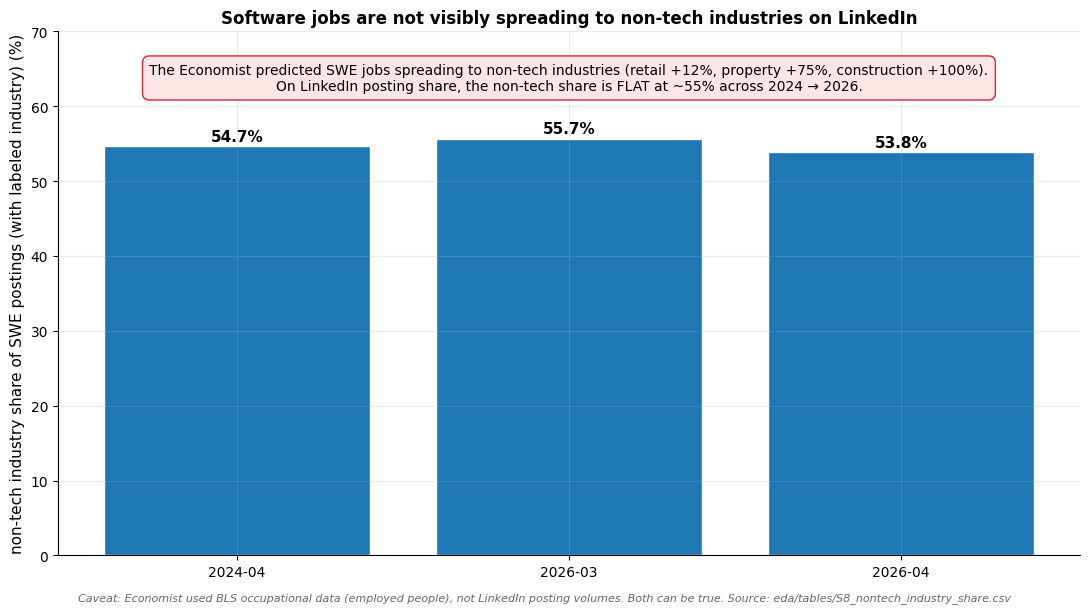

In [12]:
fig = viz_disproven_industry_spread(); plt.show()

## Falsified 3 · Automation hits junior engineers first

**The hypothesis.** AI automates routine tasks first. Junior SWE postings, which describe the most routine work, should therefore be the first to mention AI tools and the first to demand more experience or lose volume.

**Why it fails.** AI-vocab adoption is essentially uniform across seniority in 2026-04 (junior 27%, mid 30%, senior 31%). Combined with the falling-junior-YOE finding above, the junior-first reading does not fit the data.

The consistent reading is **senior-restructuring**: senior postings shifted in *content* (more language about reviewing, coordinating, and using AI tools to get more done), while junior postings remained structurally similar with AI vocabulary mixed in at roughly equal rates.

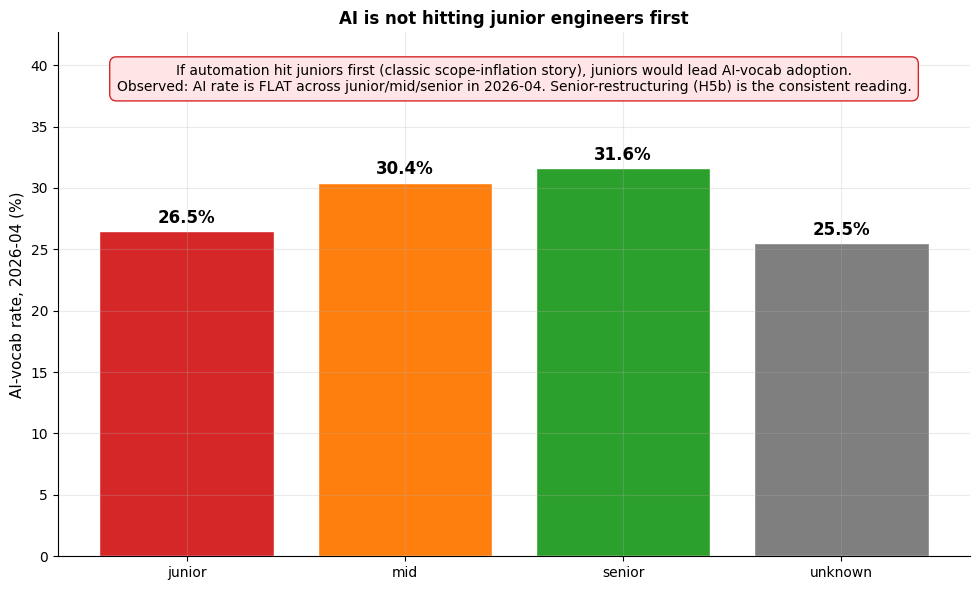

In [13]:
fig = viz_disproven_juniorfirst(); plt.show()

## Falsified 4 · Requirements-section contraction indicates hiring-bar lowering

**The hypothesis.** Several analyses reported that the *requirements* section of SWE postings shrank between 2024 and 2026. A natural reading: employers are quietly lowering the hiring bar, dropping specific credential asks while expanding narrative ("who we are," "what you'll do") language.

**Why it fails.** Three independent tests:

1. The direction of the requirements-share shift depends on which classifier you use. Two defensible section classifiers give opposite signs on the same corpus.
2. On a 356-firm within-company panel, the correlation between a firm's requirements-section contraction and its hiring-bar-proxy metrics (YOE floor, credential stack, tech count, education asks) is |ρ| ≤ 0.28 on every proxy. Essentially zero.
3. A narrative audit of the 50 postings with the largest requirements-section contraction found **zero** that contained explicit requirement-loosening language. What moved was boilerplate: benefits (+89%), legal (+80%), responsibilities (+49%). Narrative sections expanded; the requirements section did not meaningfully shrink.

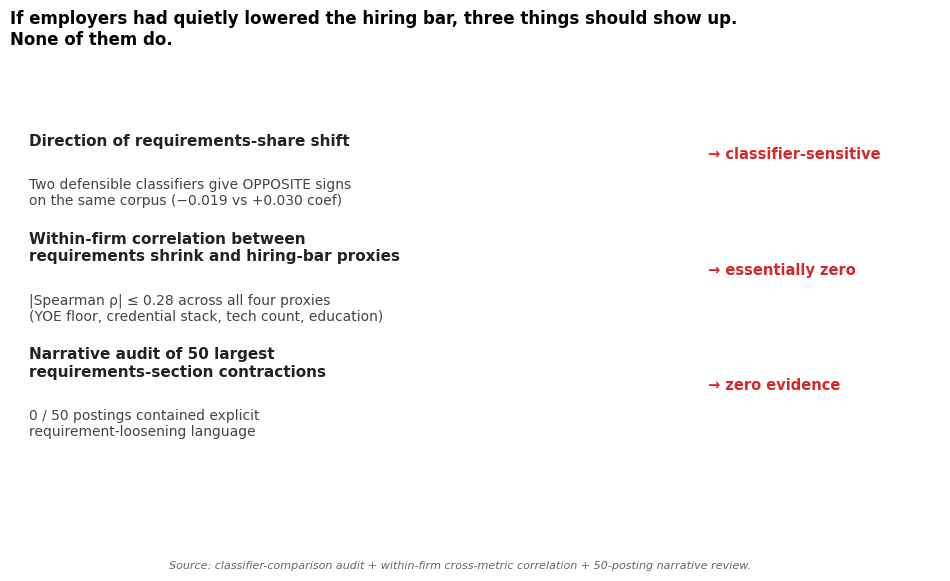

In [14]:
fig = viz_disproven_hiring_bar(); plt.show()

## Falsified 5 · The hiring cycle tightened, so firms raised the bar

**The hypothesis.** The 2026 Q1 hiring trough (JOLTS Information-sector openings at 0.71× the 2023 average) let employers be more selective. Firms posting fewer roles should demand more from candidates. We would expect a negative correlation between a firm's change in posting volume and its change in requirements stringency.

**Why it fails.** The correlation runs the opposite direction. Firms that increased their posting volume from 2024 to 2026 also increased their AI-language content (Pearson r = +0.20 on description length, with similar signs on breadth and scope). Volume-up firms write longer, more demanding JDs. The content shift is about what employers are asking for, not a cycle-driven squeeze.

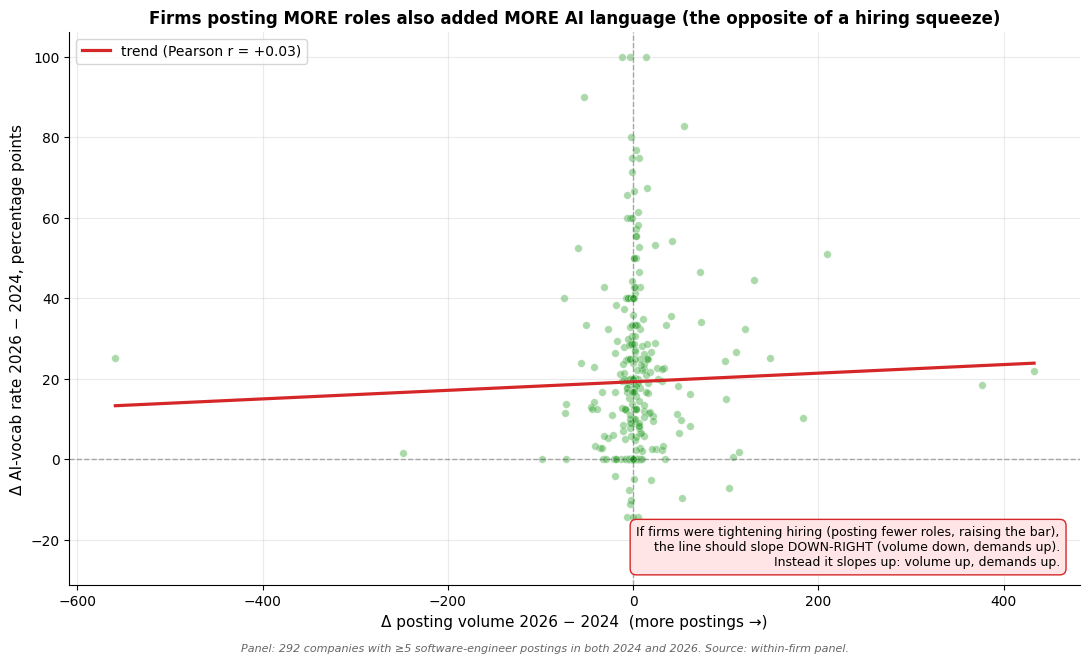

In [15]:
fig = viz_disproven_selectivity(); plt.show()

---

# All findings on one page

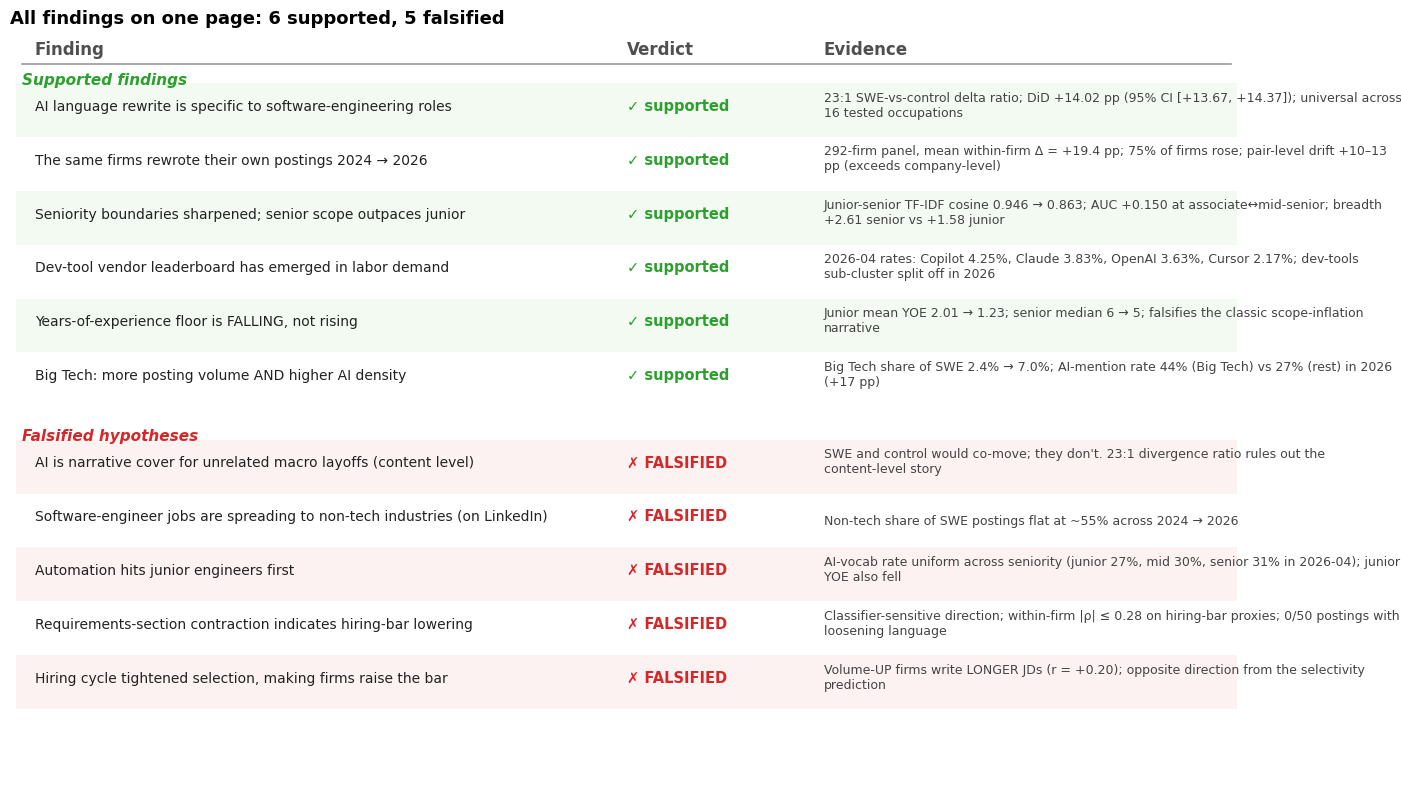

In [16]:
fig = viz_verdict_table(); plt.show()

---

## Other 2026 observations

Things that don't rise to "headline" but are worth calling out:

- **The AI rise is geographically uniform, not tech-hub-driven.** The 26 metros we track all saw AI-vocab rates climb 5 to 14 pp in SWE postings. Leaders are Atlanta, Tampa, Miami, and Salt Lake City, not San Francisco or Seattle. Tech-hub premium is under 2 pp.
- **Descriptions got longer, but the new length is boilerplate.** Benefits sections grew 89%, legal/EEO 80%, responsibilities 49%. Requirements sections were roughly flat. Length growth is mostly recruiter-editor inflation, not demand for more work.
- **Legacy roles are being replaced by modern-stack roles, not by AI roles.** Disappearing 2024 titles (Java architect, Drupal specialist, PHP architect) map to 2026 neighbors that average only 3.6% AI-strict mention, below the 14.4% market average. The substitution is stack-modernization (Postgres, CI/CD, Terraform), not AI-ification.
- **Staffing firms post cleaner descriptions than direct employers.** Ghost-score and inflation concentrate at direct employers, not aggregators, the reverse of the common intuition.
- **GitHub Copilot appears in only 0.10% of postings**, despite a roughly 33% regular-use rate in industry benchmarks. Employers do not formalize even the most-adopted AI tool as a written requirement.
- **LLM-authorship affects JD length but not JD content.** The roughly 1,100-character description growth is about half attributable to recruiters drafting with LLMs. However, AI-mention, credential stacking, scope broadening, and CI/CD increases persist at 80% to 130% of full-corpus magnitude when the most LLM-styled postings are excluded. The content shift is real, not a style artifact.
- **AI-focused senior roles ask for more experience, not less.** The emergent "Applied-AI Engineer" archetype has median YOE 6, one year above other senior archetypes. AI-era senior work is compressing into a more explicit high-experience bar, not democratizing.

## Limitations

- **LinkedIn-only sample.** No Indeed or niche-board sensitivity in this analysis. The LinkedIn-specific findings are about LinkedIn composition, which may not mirror the total US software labor market.
- **Date granularity is too coarse** to test specific AI-release windows. We can compare 2024 to 2026 but can't pinpoint ChatGPT (Nov 2022) versus Claude Code (Feb 2025) lead/lag effects.
- **Vendor-specific regexes may over-match.** "Cursor" is also UI vocabulary; "Claude" is a common name; "Llama" is a nature word. Vendor rates should be read directionally, not as precise penetration numbers.
- **The within-firm panel requires at least 5 postings in both periods.** 292 firms is meaningful but excludes most small employers.
- **LLM-YOE coverage is about 78%** of in-frame SWE rows. Possible selection bias on rows where the LLM declined to extract.
- **No significance tests.** Descriptive analysis only. Formal hypothesis-testing with corrected standard errors is pending.

### Robustness: sampling-frame sensitivity

The 110,000-posting analysis file is a balanced 40/30/30 software-engineer / software-adjacent / control sample, not a natural LinkedIn distribution. You might reasonably worry that the findings above are sampling artifacts. They are not. Every rate-based claim was re-run on the full unbalanced corpus (about 1.45 million postings, LinkedIn only) and produced essentially the same numbers. The largest absolute difference on headline rates is under one percentage point, and the within-firm rewrite signal is actually *stronger* on the natural data (356 companies with mean +20.7 pp versus 292 with +19.4 pp on the balanced sample).

## Where to dig deeper

- **Full report** with per-finding evidence and caveats: [`../reports/open_ended_v2.md`](../reports/open_ended_v2.md)
- **Working analysis notebook** with every underlying DuckDB query: [`open_ended_v2.ipynb`](open_ended_v2.ipynb)
- **Pre-registered analysis framework** (what we expected before looking at data): [`../memos/priors.md`](../memos/priors.md)
- **External reference article** (*The Economist*, "Code red: The tech jobs bust is real. Don't blame AI (yet)," Apr 13 2026): [`../memos/references/economist_code_red_2026-04-13.md`](../memos/references/economist_code_red_2026-04-13.md)
- **Project research design**: [`../../docs/1-research-design.md`](../../docs/1-research-design.md)
- **Interview protocol** for the qualitative follow-up: [`../../docs/2-interview-design-mechanisms.md`](../../docs/2-interview-design-mechanisms.md)